In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import plotly.graph_objects as go



In [74]:
# Load a specific sheet
results = pd.read_excel('Concept testing.xlsx', sheet_name='Python')

overall_results = results[results['Delay'] == 'Overall']

minutes = [3,4,5,6,7,8,9,10,11,12,13,14,15,20,25]
minute_results = {}

for m in minutes:
    minute_results[m] = results[results['Delay'] == f'{m} minute']
    

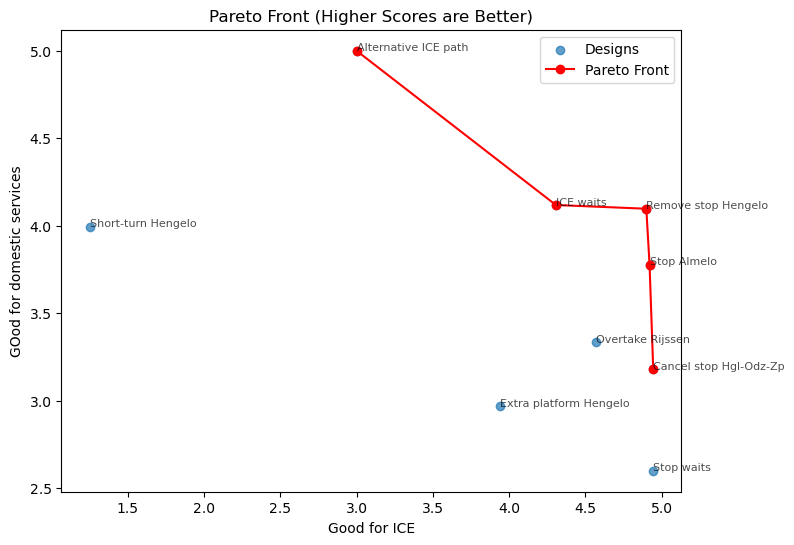

In [68]:
# Step 1: Compute 2 category scores
results['Cat1'] = overall_results[['KPI1','KPI2','KPI6','KPI8']].mean(axis=1)
results['Cat2'] = overall_results[['KPI3','KPI4','KPI5','KPI7','KPI8']].mean(axis=1)

# Step 2: Pareto front function (for maximization)
def pareto_front_max(df, x_col, y_col):
    points = df[[x_col, y_col]].values
    is_pareto = np.ones(points.shape[0], dtype=bool)
    for i, point in enumerate(points):
        if is_pareto[i]:
            # A point is dominated if there exists another point better in both x and y
            is_dominated = np.any((points[:,0] >= point[0]) & (points[:,1] >= point[1]) & ((points[:,0] > point[0]) | (points[:,1] > point[1])))
            if is_dominated:
                is_pareto[i] = False
    return df[is_pareto]

# Step 3: Compute Pareto front
pareto_df = pareto_front_max(results, 'Cat1', 'Cat2')

# Step 4: Sort Pareto points for line plotting
pareto_df = pareto_df.sort_values(by='Cat1', ascending=True)

# Step 5: Plot
plt.figure(figsize=(8,6))
plt.scatter(results['Cat1'], results['Cat2'], label='Designs', alpha=0.7)
plt.plot(pareto_df['Cat1'], pareto_df['Cat2'], color='red', marker='o', label='Pareto Front')
for i, txt in enumerate(results['Unnamed: 0']):
    plt.annotate(txt, (results['Cat1'][i], results['Cat2'][i]), fontsize=8, alpha=0.7)
plt.xlabel('Good for ICE')
plt.ylabel('GOod for domestic services')
plt.title('Pareto Front (Higher Scores are Better)')
plt.legend()
plt.show()


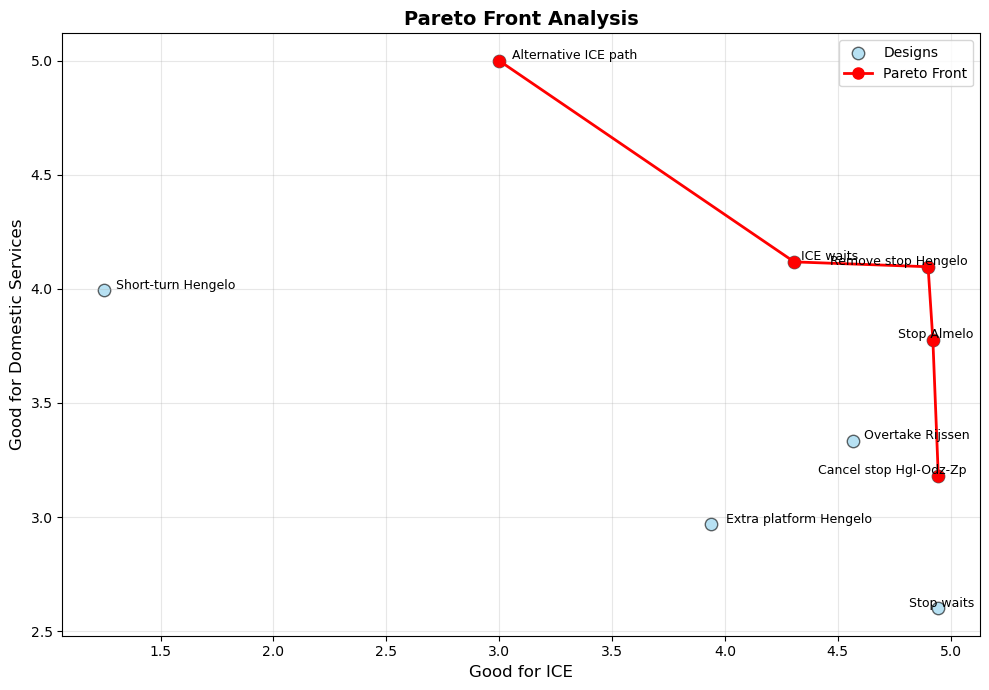

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text  # optional, for better annotation placement

# Step 1: Compute 2 category scores
results['Cat1'] = overall_results[['KPI1','KPI2','KPI6','KPI8']].mean(axis=1)
results['Cat2'] = overall_results[['KPI3','KPI4','KPI5','KPI7','KPI8']].mean(axis=1)

# Step 2: Pareto front function (for maximization)
def pareto_front_max(df, x_col, y_col):
    points = df[[x_col, y_col]].values
    is_pareto = np.ones(points.shape[0], dtype=bool)
    for i, point in enumerate(points):
        if is_pareto[i]:
            is_dominated = np.any((points[:,0] >= point[0]) & (points[:,1] >= point[1]) & ((points[:,0] > point[0]) | (points[:,1] > point[1])))
            if is_dominated:
                is_pareto[i] = False
    return df[is_pareto]

# Step 3: Compute Pareto front
pareto_df = pareto_front_max(results, 'Cat1', 'Cat2').sort_values(by='Cat1')

# Step 4: Plot
plt.figure(figsize=(10,7))
plt.scatter(results['Cat1'], results['Cat2'], label='Designs', alpha=0.6, edgecolor='k', s=80, color='skyblue')
plt.plot(pareto_df['Cat1'], pareto_df['Cat2'], color='red', marker='o', linestyle='-', linewidth=2, markersize=8, label='Pareto Front')

# Annotations (optional: adjust to avoid overlap)
texts = []
for i, txt in enumerate(results['Unnamed: 0']):
    texts.append(plt.text(results['Cat1'][i], results['Cat2'][i], txt, fontsize=9))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.xlabel('Good for ICE', fontsize=12)
plt.ylabel('Good for Domestic Services', fontsize=12)
plt.title('Pareto Front Analysis', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


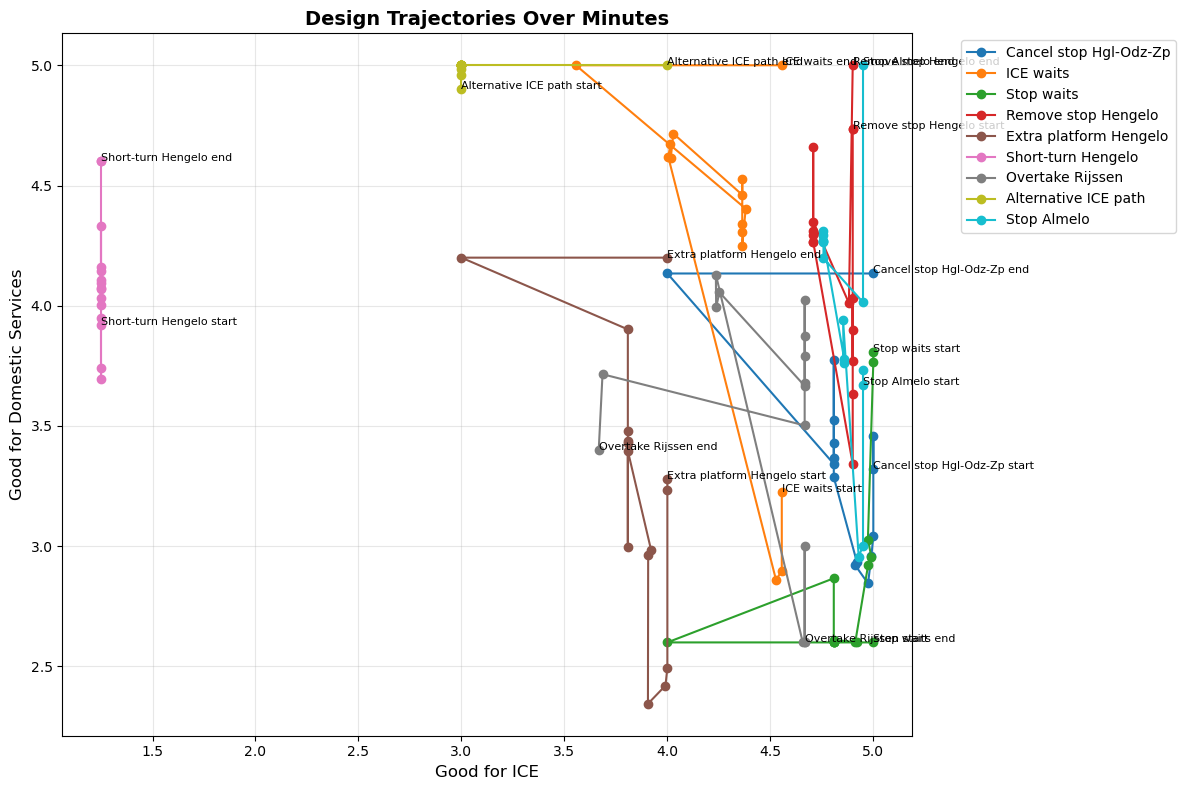

In [51]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

plt.figure(figsize=(12,8))

# Colors for each design
designs = overall_results['Unnamed: 0'].tolist()  # list of design names
colors = plt.cm.tab10(np.linspace(0,1,len(designs)))  # one color per design

for i, design in enumerate(designs):
    cat1_scores = []
    cat2_scores = []
    
    for m in minutes:
        df = minute_results[m]
        df_design = df[df['Unnamed: 0'] == design]
        
        # Compute Cat1 and Cat2
        cat1 = df_design[['KPI1','KPI2','KPI6','KPI8']].mean(axis=1).values[0]
        cat2 = df_design[['KPI3','KPI4','KPI5','KPI7','KPI8']].mean(axis=1).values[0]
        
        cat1_scores.append(cat1)
        cat2_scores.append(cat2)
    
    # Plot trajectory of this design over time
    plt.plot(cat1_scores, cat2_scores, marker='o', color=colors[i], label=design)
    
    # Optional: annotate first and last points
    plt.text(cat1_scores[0], cat2_scores[0], f'{design} start', fontsize=8)
    plt.text(cat1_scores[-1], cat2_scores[-1], f'{design} end', fontsize=8)

plt.xlabel('Good for ICE', fontsize=12)
plt.ylabel('Good for Domestic Services', fontsize=12)
plt.title('Design Trajectories Over Minutes', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
#Plotly rechte lijn

# Step 1: Compute 2 category scores
results['Cat1'] = overall_results[['KPI1','KPI2','KPI6','KPI8']].mean(axis=1)
results['Cat2'] = overall_results[['KPI3','KPI4','KPI5','KPI7','KPI8']].mean(axis=1)

# Step 2: Pareto front function (for maximization)
def pareto_front_max(df, x_col, y_col):
    points = df[[x_col, y_col]].values
    is_pareto = np.ones(points.shape[0], dtype=bool)

    for i, point in enumerate(points):
        if is_pareto[i]:
            dominated = np.any(
                (points[:, 0] >= point[0]) &
                (points[:, 1] >= point[1]) &
                ((points[:, 0] > point[0]) | (points[:, 1] > point[1]))
            )
            if dominated:
                is_pareto[i] = False

    return df[is_pareto]

# Step 3: Compute Pareto front
pareto_df = pareto_front_max(results, 'Cat1', 'Cat2').sort_values('Cat1')

# Step 4: Plot with Plotly
fig = go.Figure()

# All designs
fig.add_trace(go.Scatter(
    x=results['Cat1'],
    y=results['Cat2'],
    mode='markers+text',
    text=results['Unnamed: 0'],
    textposition='top center',
    name='Designs',
    marker=dict(
        size=10,
        color='skyblue',
        line=dict(width=1, color='black'),
        opacity=0.7
    ),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Cat1: %{x:.2f}<br>"
        "Cat2: %{y:.2f}<extra></extra>"
    )
))

# Pareto front
fig.add_trace(go.Scatter(
    x=pareto_df['Cat1'],
    y=pareto_df['Cat2'],
    mode='lines+markers',
    name='Pareto Front',
    line=dict(color='red', width=2),
    marker=dict(size=9, color='red')
))

# Layout
fig.update_layout(
    title=dict(
        text='Pareto Front Analysis',
        x=0.5,
        font=dict(size=16)
    ),
    xaxis_title='Good for ICE',
    yaxis_title='Good for Domestic Services',
    template='plotly_white',
    legend=dict(x=0.02, y=0.98),
    width=900,
    height=650
)

fig.show()


In [ ]:
#plotly scheve lijn

import numpy as np
import plotly.graph_objects as go

# --------------------------------------------------
# Step 1: Compute 2 category scores
# --------------------------------------------------
results['Cat1'] = overall_results[['KPI1','KPI2','KPI6','KPI8']].mean(axis=1)
results['Cat2'] = results[['KPI3','KPI4','KPI5','KPI7','KPI8']].mean(axis=1)

# --------------------------------------------------
# Step 2: Pareto front function (maximization)
# --------------------------------------------------
def pareto_front_max(df, x_col, y_col):
    points = df[[x_col, y_col]].values
    is_pareto = np.ones(points.shape[0], dtype=bool)

    for i, point in enumerate(points):
        if is_pareto[i]:
            dominated = np.any(
                (points[:, 0] >= point[0]) &
                (points[:, 1] >= point[1]) &
                ((points[:, 0] > point[0]) | (points[:, 1] > point[1]))
            )
            if dominated:
                is_pareto[i] = False

    return df[is_pareto]

# --------------------------------------------------
# Step 3: Compute Pareto front
# --------------------------------------------------
pareto_df = pareto_front_max(results, 'Cat1', 'Cat2').sort_values('Cat1')

# --------------------------------------------------
# Step 4: Plot with Plotly
# --------------------------------------------------
fig = go.Figure()

# All designs
fig.add_trace(go.Scatter(
    x=results['Cat1'],
    y=results['Cat2'],
    mode='markers+text',
    text=results['Unnamed: 0'],
    textposition='top center',
    name='Designs',
    marker=dict(
        size=10,
        color='skyblue',
        opacity=0.7,
        line=dict(width=1, color='black')
    ),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Good for ICE: %{x:.2f}<br>"
        "Good for Domestic Services: %{y:.2f}"
        "<extra></extra>"
    )
))

# Pareto front (smooth + circular)
fig.add_trace(go.Scatter(
    x=pareto_df['Cat1'],
    y=pareto_df['Cat2'],
    mode='lines+markers',
    name='Pareto Front',
    line=dict(
        color='red',
        width=3,
        shape='spline',
        smoothing=1.3
    ),
    marker=dict(
        symbol='circle',
        size=14,
        color='red',
        line=dict(width=2, color='darkred')
    ),
    hoverinfo='skip'
))

# --------------------------------------------------
# Layout styling
# --------------------------------------------------
fig.update_layout(
    title=dict(
        text='Pareto Front Analysis',
        x=0.5,
        font=dict(size=16)
    ),
    xaxis=dict(
        title='Good for ICE',
        gridcolor='rgba(0,0,0,0.15)'
    ),
    yaxis=dict(
        title='Good for Domestic Services',
        gridcolor='rgba(0,0,0,0.15)'
    ),
    template='plotly_white',
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)'
    ),
    width=900,
    height=650
)

fig.show()


In [ ]:
#plotly minuut

import numpy as np
import plotly.graph_objects as go

# --------------------------------------------------
# Step 0: Select the 3-minute results
# --------------------------------------------------
df = minute_results[12].copy()

# --------------------------------------------------
# Step 1: Compute 2 category scores
# --------------------------------------------------
df['Cat1'] = df[['KPI1','KPI2','KPI6','KPI8']].mean(axis=1)
df['Cat2'] = df[['KPI3','KPI4','KPI5','KPI7','KPI8']].mean(axis=1)

# --------------------------------------------------
# Step 2: Pareto front function (maximization)
# --------------------------------------------------
def pareto_front_max(df, x_col, y_col):
    points = df[[x_col, y_col]].values
    is_pareto = np.ones(points.shape[0], dtype=bool)

    for i, point in enumerate(points):
        if is_pareto[i]:
            dominated = np.any(
                (points[:, 0] >= point[0]) &
                (points[:, 1] >= point[1]) &
                ((points[:, 0] > point[0]) | (points[:, 1] > point[1]))
            )
            if dominated:
                is_pareto[i] = False

    return df[is_pareto]

# --------------------------------------------------
# Step 3: Compute Pareto front
# --------------------------------------------------
pareto_df = pareto_front_max(df, 'Cat1', 'Cat2').sort_values('Cat1')

# --------------------------------------------------
# Step 4: Plot with Plotly
# --------------------------------------------------
fig = go.Figure()

# All designs
fig.add_trace(go.Scatter(
    x=df['Cat1'],
    y=df['Cat2'],
    mode='markers+text',
    text=df['Unnamed: 0'],
    textposition='top center',
    name='Designs (3 min)',
    marker=dict(
        size=10,
        color='skyblue',
        opacity=0.7,
        line=dict(width=1, color='black')
    ),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Good for ICE: %{x:.2f}<br>"
        "Good for Domestic Services: %{y:.2f}"
        "<extra></extra>"
    )
))

# Pareto front (smooth + circular)
fig.add_trace(go.Scatter(
    x=pareto_df['Cat1'],
    y=pareto_df['Cat2'],
    mode='lines+markers',
    name='Pareto Front (3 min)',
    line=dict(
        color='red',
        width=3,
        shape='spline',
        smoothing=1.3
    ),
    marker=dict(
        symbol='circle',
        size=14,
        color='red',
        line=dict(width=2, color='darkred')
    ),
    hoverinfo='skip'
))

# --------------------------------------------------
# Layout styling
# --------------------------------------------------
fig.update_layout(
    title=dict(
        text='Pareto Front Analysis – 3 Minute Delay',
        x=0.5,
        font=dict(size=16)
    ),
    xaxis=dict(
        title='Good for ICE',
        gridcolor='rgba(0,0,0,0.15)'
    ),
    yaxis=dict(
        title='Good for Domestic Services',
        gridcolor='rgba(0,0,0,0.15)'
    ),
    template='plotly_white',
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)'
    ),
    width=900,
    height=650
)

fig.show()
